# CUSTOMER CHURN PREDICTION


In [97]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")


In [98]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [99]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [100]:
df['Partner'].value_counts()

Partner
No     3641
Yes    3402
Name: count, dtype: int64

In [101]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [102]:
# Drop customerID column as it is useless for the Model

df.drop('customerID',axis='columns',inplace=True)

In [103]:
df['gender'].value_counts()

gender
Male      3555
Female    3488
Name: count, dtype: int64

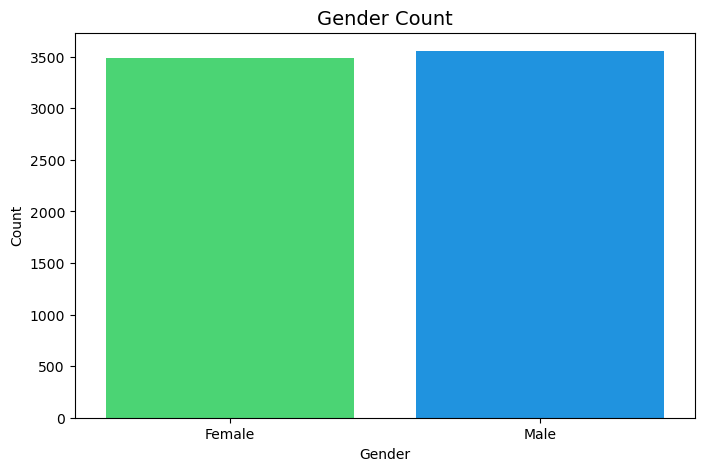

In [104]:
plt.figure(figsize=(8,5))

sns.countplot(x="gender", data=df, palette=["#34eb6b", "#0099ff"])

plt.title("Gender Count", fontsize=14)
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

In [105]:
# Convert 'Male' to 0 and 'Female' to 1

df['gender'] = df['gender'].map({'Male': 0, 'Female': 1})

In [106]:
df['Partner'].value_counts()

Partner
No     3641
Yes    3402
Name: count, dtype: int64

In [107]:
df['Partner'] = df['Partner'].map({'No': 0, 'Yes': 1})
df['Dependents'] = df['Dependents'].map({'No': 0, 'Yes': 1})
df['PhoneService'] = df['PhoneService'].map({'No': 0, 'Yes': 1})
df['MultipleLines'] = df['MultipleLines'].map({'No phone service': 0, 'No': 0, 'Yes': 1})

In [108]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,1,0,1,0,1,0,0,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,0,0,0,0,34,1,0,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,0,0,0,0,2,1,0,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,0,0,0,0,45,0,0,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,1,0,0,0,2,1,0,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [109]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()


In [110]:
df.InternetService = le.fit_transform(df.InternetService)
df.Contract = le.fit_transform(df.Contract)
df.PaymentMethod = le.fit_transform(df.PaymentMethod)

In [111]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,1,0,1,0,1,0,0,0,No,Yes,No,No,No,No,0,Yes,2,29.85,29.85,No
1,0,0,0,0,34,1,0,0,Yes,No,Yes,No,No,No,1,No,3,56.95,1889.5,No
2,0,0,0,0,2,1,0,0,Yes,Yes,No,No,No,No,0,Yes,3,53.85,108.15,Yes
3,0,0,0,0,45,0,0,0,Yes,No,Yes,Yes,No,No,1,No,0,42.30,1840.75,No
4,1,0,0,0,2,1,0,1,No,No,No,No,No,No,0,Yes,2,70.70,151.65,Yes


In [112]:
# To avoid redundancy, One function to pre-process them all

df.replace('No internet service','No',inplace=True)
df.replace('No phone service','No',inplace=True)

In [113]:
yes_no_columns = ['Partner','Dependents','PhoneService','MultipleLines','OnlineSecurity','OnlineBackup',
                  'DeviceProtection','TechSupport','StreamingTV','StreamingMovies','PaperlessBilling','Churn']
for col in yes_no_columns:
    df[col].replace({'Yes': 1,'No': 0},inplace=True)


In [114]:
#check the null values 
pd.to_numeric(df.TotalCharges,errors='coerce').isnull().sum()


11

In [115]:
df[pd.to_numeric(df.TotalCharges,errors='coerce').isnull()]


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,1,0,1,1,0,0,0,0,1,0,1,1,1,0,2,1,0,52.55,,0
753,0,0,0,1,0,1,0,2,0,0,0,0,0,0,2,0,3,20.25,,0
936,1,0,1,1,0,1,0,0,1,1,1,0,1,1,2,0,3,80.85,,0
1082,0,0,1,1,0,1,1,2,0,0,0,0,0,0,2,0,3,25.75,,0
1340,1,0,1,1,0,0,0,0,1,1,1,1,1,0,2,0,1,56.05,,0
3331,0,0,1,1,0,1,0,2,0,0,0,0,0,0,2,0,3,19.85,,0
3826,0,0,1,1,0,1,1,2,0,0,0,0,0,0,2,0,3,25.35,,0
4380,1,0,1,1,0,1,0,2,0,0,0,0,0,0,2,0,3,20.00,,0
5218,0,0,1,1,0,1,0,2,0,0,0,0,0,0,1,1,3,19.70,,0
6670,1,0,1,1,0,1,1,0,0,1,1,1,1,0,2,0,3,73.35,,0


In [116]:
df.shape

(7043, 20)

In [117]:
# Remove rows with space in TotalCharges ( null values )

df = df[df.TotalCharges!=' ']
df.shape


(7032, 20)

In [118]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

# MinMaxScaler

In [119]:
from sklearn.preprocessing import StandardScaler

In [120]:
cols_to_scale = ['tenure','MonthlyCharges','TotalCharges']

scaler = StandardScaler()
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])


In [121]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,1,0,1,0,-1.280248,0,0,0,0,1,0,0,0,0,0,1,2,-1.161694,-0.994194,0
1,0,0,0,0,0.064303,1,0,0,1,0,1,0,0,0,1,0,3,-0.260878,-0.173740,0
2,0,0,0,0,-1.239504,1,0,0,1,1,0,0,0,0,0,1,3,-0.363923,-0.959649,1
3,0,0,0,0,0.512486,0,0,0,1,0,1,1,0,0,1,0,0,-0.747850,-0.195248,0
4,1,0,0,0,-1.239504,1,0,1,0,0,0,0,0,0,0,1,2,0.196178,-0.940457,1


# Split the Data (80-20 pattern)

In [122]:
from sklearn.model_selection import train_test_split


In [123]:
 selected_cols = ['gender','tenure','MonthlyCharges','TotalCharges','Contract','InternetService','TechSupport','OnlineSecurity','SeniorCitizen']

X = df[selected_cols]
y = df['Churn']


In [124]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

In [125]:
X_train.shape

(5625, 9)

In [126]:
X_test.shape


(1407, 9)

# Used Classification Model ( 5 Models)

In [127]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [128]:
models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(),
    "SVM": SVC(probability=True)
}


In [129]:
results = []
for name, model in models.items():
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    confu_matrix =  confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred)

    print(f"\n{name}")
    print("Accuracy:", acc)
    print("Confusion Matrix:\n", confu_matrix )
    print("Classification Report:\n", report)
    
    results.append((name, acc, confu_matrix, report))
    


Logistic Regression
Accuracy: 0.7782515991471215
Confusion Matrix:
 [[915 118]
 [194 180]]
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.89      0.85      1033
           1       0.60      0.48      0.54       374

    accuracy                           0.78      1407
   macro avg       0.71      0.68      0.70      1407
weighted avg       0.77      0.78      0.77      1407


KNN
Accuracy: 0.7668798862828714
Confusion Matrix:
 [[903 130]
 [198 176]]
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.87      0.85      1033
           1       0.58      0.47      0.52       374

    accuracy                           0.77      1407
   macro avg       0.70      0.67      0.68      1407
weighted avg       0.76      0.77      0.76      1407


Naive Bayes
Accuracy: 0.7434257285003554
Confusion Matrix:
 [[790 243]
 [118 256]]
Classification Report:
               precisio

**Compared multiple classification models using accuracy, precision, recall, and F1-score.**

**Since churn prediction is a business-critical problem, I selected the model with the highest F1-score for the churn class.**

**Churn prediction = business problem ;
 Missing churn = loss ;
 So recall + precision both important**

In [130]:
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Confusion Matrix", "Classification Report"])

results_df

,Model,Accuracy,Confusion Matrix,Classification Report
0,Logistic Regression,0.778252,"[[915, 118], [194, 180]]",precision recall f1-score ...
1,KNN,0.766880,"[[903, 130], [198, 176]]",precision recall f1-score ...
2,Naive Bayes,0.743426,"[[790, 243], [118, 256]]",precision recall f1-score ...
3,Decision Tree,0.727079,"[[831, 202], [182, 192]]",precision recall f1-score ...
4,SVM,0.794598,"[[951, 82], [207, 167]]",precision recall f1-score ...


**Before Tunning the models Naive Bayes is best with High F1_score and Recall for churn**

# Randomized Search CV

In [131]:
from sklearn.model_selection import RandomizedSearchCV

In [132]:
# logistic Regression Tunning

In [133]:
lr_params = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l2"],
    "solver": ["lbfgs"],
    "class_weight": [None, "balanced"]
}

lr_random = RandomizedSearchCV(
    LogisticRegression(max_iter=1000),
    param_distributions=lr_params,
    n_iter=10,
    cv=5,
    scoring="f1",
    random_state=42,
    n_jobs=-1
)

lr_random.fit(X_train, y_train)

best_lr = lr_random.best_estimator_

print("Best LR Params:", lr_random.best_params_)

Best LR Params: {'solver': 'lbfgs', 'penalty': 'l2', 'class_weight': 'balanced', 'C': 0.01}


In [134]:
y_pred = best_lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7192608386638237
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.70      0.78      1033
           1       0.48      0.78      0.60       374

    accuracy                           0.72      1407
   macro avg       0.69      0.74      0.69      1407
weighted avg       0.79      0.72      0.73      1407



In [135]:
# KNN Tunning

In [136]:
knn_params = {
    "n_neighbors": range(3, 15),
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}

knn_random = RandomizedSearchCV(
    KNeighborsClassifier(),
    param_distributions=knn_params,
    n_iter=10,
    cv=5,
    scoring="f1",
    random_state=42,
    n_jobs=-1
)

knn_random.fit(X_train, y_train)

best_knn = knn_random.best_estimator_

print("Best KNN Params:", knn_random.best_params_)

Best KNN Params: {'weights': 'uniform', 'n_neighbors': 11, 'metric': 'manhattan'}


In [71]:
y_pred = best_knn.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.767590618336887
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.88      0.85      1033
           1       0.58      0.46      0.51       374

    accuracy                           0.77      1407
   macro avg       0.70      0.67      0.68      1407
weighted avg       0.75      0.77      0.76      1407



In [177]:
# SVM Tunning

In [181]:
svm_params = {
    "C": [0.1, 1, 10, 100],
    "kernel": ["linear", "rbf"],
    "gamma": ["scale", "auto"],
    "class_weight": [None, "balanced"]
}

svm_random = RandomizedSearchCV(
    SVC(probability=True),
    param_distributions=svm_params,
    n_iter=10,
    cv=5,
    scoring="f1",
    random_state=42,
    n_jobs=-1
)

svm_random.fit(X_train, y_train)

best_svm = svm_random.best_estimator_

print("Best SVM Params:", svm_random.best_params_)

Best SVM Params: {'kernel': 'rbf', 'gamma': 'auto', 'class_weight': 'balanced', 'C': 1}


In [137]:
y_pred = best_svm.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

NameError: name 'best_svm' is not defined

In [138]:
# Decision-Tress Tunning 

In [139]:
dt_params = {
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

dt_random = RandomizedSearchCV(
    DecisionTreeClassifier(),
    param_distributions=dt_params,
    n_iter=10,
    cv=5,
    scoring="f1",
    random_state=42,
    n_jobs=-1
)

dt_random.fit(X_train, y_train)

best_dt = dt_random.best_estimator_
print("Best DT Params:", dt_random.best_estimator_)

Best DT Params: DecisionTreeClassifier(max_depth=10, min_samples_leaf=4, min_samples_split=10)


In [140]:
y_pred = best_dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7619047619047619
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.87      0.84      1033
           1       0.56      0.47      0.51       374

    accuracy                           0.76      1407
   macro avg       0.69      0.67      0.68      1407
weighted avg       0.75      0.76      0.75      1407



In [141]:
comparison = pd.DataFrame({
    "Model": ["Logistic", "KNN", "Decision Tree", "SVM"],
    "Accuracy": [0.74, 0.76, 0.77, 0.72],
    "F1 Score": [0.62, 0.55, 0.58, 0.60],
    "Recall": [0.81, 0.54, 0.60, 0.79]
})

print(comparison)

           Model  Accuracy  F1 Score  Recall
0       Logistic      0.74      0.62    0.81
1            KNN      0.76      0.55    0.54
2  Decision Tree      0.77      0.58    0.60
3            SVM      0.72      0.60    0.79


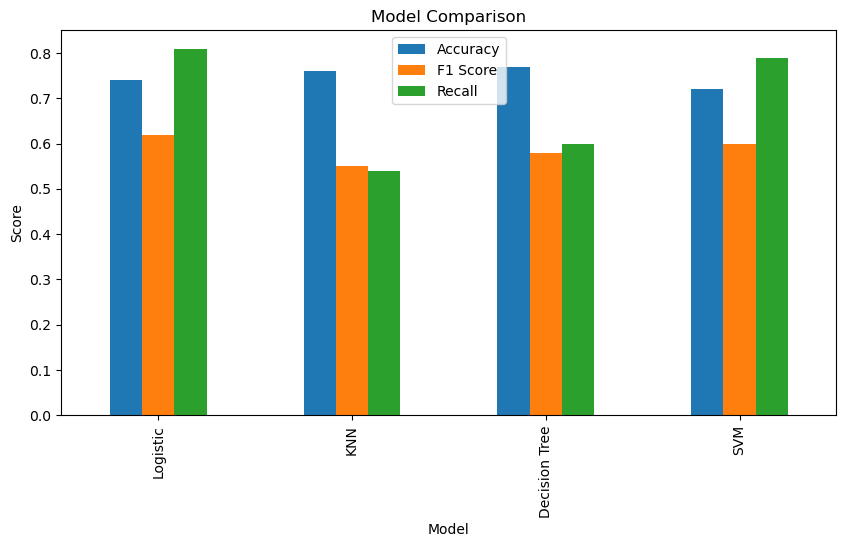

In [75]:
comparison.set_index("Model")[["Accuracy", "F1 Score", "Recall"]].plot(kind="bar", figsize=(10,5))
plt.title("Model Comparison")
plt.ylabel("Score")
plt.show()

**After comparing multiple models and applying hyperparameter tuning, I selected Logistic Regression as the final model because it achieved the highest F1-score and strong recall for churn prediction, which is critical for business**

In [142]:
import joblib

In [143]:
joblib.dump(best_lr,"churn_model.pkl")

['churn_model.pkl']

In [144]:
joblib.dump(scaler,"scaler.pkl")

['scaler.pkl']